edge_knots=[0.0, 0.0, 0.25, 0.5, 0.75, 1.0, 1.0]


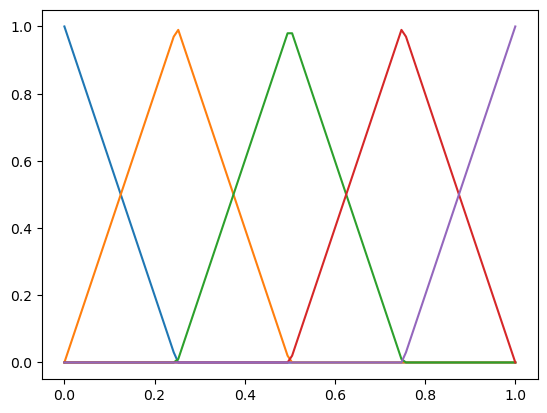

In [7]:
# 1d iga basis assembly

import numpy as np
import matplotlib.pyplot as plt

nxe = 4

def linear_bernstein(xi):
    N = np.array([1-xi, xi])
    dN = np.array([-1, 1])
    return N, dN

# now assemble 1d iga basis of 1st order first..
p = 1
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
ndegen_knots = knots[p:-p]
edge_knots = knots
print(f"{edge_knots=}")
# print(f"{ndegen_knots=}")
nnodes = nxe + p
nplot = 100
u = np.linspace(0.0, 1.0, nplot)

Y = np.zeros((nnodes, nplot))
for ielem in range(nxe):
    loc_conn = [[ielem, ielem+1]]
    # how to check if it's in global basis?
    knot1, knot2 = ndegen_knots[ielem], ndegen_knots[ielem+1]
    # print(f"{knot1=} {knot2=}")
    xi = (u - knot1) / (knot2 - knot1)
    # print(f"{xi=}")
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)

    N, _ = linear_bernstein(xi)
    Y[ielem,:] += N[0] * xi_mask
    Y[ielem+1,:] += N[1] * xi_mask

# plot each basis function now
for i in range(nnodes):
    plt.plot(u, Y[i,:])
plt.show()



vertex_knots=[0.0, 0.0, 0.0, 0.25, 0.5, 0.75, 1.0, 1.0, 1.0]


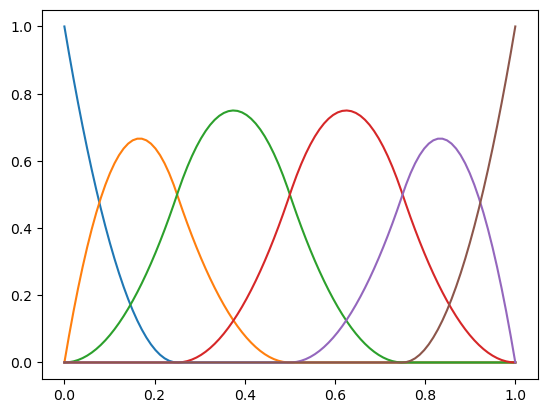

In [8]:

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN


def get_iga2_basis(xi, left_bndry, right_bndry):
    B, dB = quad_bernstein(xi)

    # bndry adjustment and regular basis
    # on GPU can code it up with ? ternary operators probably
    ZERO = np.zeros_like(B[0])
    N = 0.5 * np.array([B[0], np.sum(B) + B[1], B[2]])
    N += 0.5 * left_bndry * np.array([B[0], -B[0], ZERO])
    N += 0.5 * right_bndry * np.array([ZERO, -B[2], B[2]])

    # bndry adjustment and regular derivs
    dN = 0.5 * np.array([dB[0], np.sum(dB) + dB[1], dB[2]])
    dN += 0.5 * left_bndry * np.array([dB[0], -dB[0], ZERO])
    dN += 0.5 * right_bndry * np.array([ZERO, -dB[2], dB[2]])
    return N, dN


# now assemble 1d iga basis of 1st order first..
p = 2
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
ndegen_knots = knots[p:-p]
# print(f"{ndegen_knots=}")
vertex_knots = knots
print(f"{vertex_knots=}")
nnodes = nxe + p
nplot = 100
u = np.linspace(0.0, 1.0, nplot)

Y = np.zeros((nnodes, nplot))
for ielem in range(nxe):
    # how to check if it's in global basis?
    knot1, knot2 = ndegen_knots[ielem], ndegen_knots[ielem+1]
    # print(f"{knot1=} {knot2=}")
    xi = (u - knot1) / (knot2 - knot1)
    # print(f"{xi=}")
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)

    # N, _ = get_iga2_basis(
    #     xi,
    #     left_bndry = ielem == 0,
    #     right_bndry = ielem == nxe-1,
    # )

    # print(f"{N=}")
    # exit()

    # Y[ielem,:] += N[0] * xi_mask
    # Y[ielem+1,:] += N[1] * xi_mask
    # Y[ielem+2,:] += N[2] * xi_mask

    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    # define optional BtoN coeffs based on element position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if ielem == 0 else 0.5
    N2_B0 = 1.0 if ielem == 0 else 0.5
    N1_B2 = 0.0 if ielem == (len(ndegen_knots)-2) else 0.5
    N0_B2 = 1.0 if ielem == (len(ndegen_knots)-2) else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    Y[ielem] += N0 * xi_mask
    Y[ielem+1] += N1 * xi_mask
    Y[ielem+2] += N2 * xi_mask

# plot each basis function now
for i in range(nnodes):
    plt.plot(u, Y[i,:])
plt.show()